# Goodreads Book Genre Trends: Exploratory Data Analysis

## Project Overview

This notebook presents the exploratory data analysis for the Goodreads Book Genre Trends project.

The analysis uses the relational SQLite database created during the database creation stage. The database contains information about books, authors, genres, and the relationships between these entities.

The goal of this analysis is to investigate how book genres have changed over time and how those changes relate to reader ratings and overall genre representation.

### Research Questions

This analysis focuses on three primary questions:

1. **How has the representation of Fiction and Nonfiction changed over time?**
2. **Which specific genres are driving the changes observed in the Fiction and Nonfiction trends?**
3. **How does genre representation relate to average reader ratings and overall reader engagement?**

### Analysis Approach

The analysis is organized into three visualizations that build on one another:

**Chart 1 — Fiction vs. Nonfiction Over Time**

The first visualization establishes the broad trend by comparing the number of Fiction and Nonfiction books represented across publication years from 1900 through 2016.

**Chart 2 — Changes in Specific Genre Representation**

The second visualization moves from broad categories to individual genres. The 10 most represented genres are compared across two publication periods, 1900–1979 and 1980–2016, to identify which genres experienced the greatest increases or decreases in representation.

**Chart 3 — Genre Representation vs. Reader Ratings**

The final visualization examines whether the most heavily represented genres also tend to have different average Goodreads ratings. Point size represents the total number of Goodreads ratings, providing an additional measure of reader engagement.

### Data Considerations

The analysis uses publication years from **1900 through 2016**, matching the cleaned dataset prepared during the data preparation stage.

Books may be associated with multiple genres, so genre-based counts are not intended to represent mutually exclusive categories. A single book can therefore contribute to multiple genre totals.

Format-based categories such as `audiobook`, `ebooks`, `comics`, `picture books`, `short stories`, and `graphic novels` are excluded from the final genre-rating analysis because they describe formats or broad classifications rather than comparable literary genres.

For the genre-rating analysis, only genres containing at least **100 unique books** are included. This minimum threshold reduces the influence of genres represented by very small samples.

### Database Structure

The analysis relies on the relational database structure developed for this project:

- `books` — information about individual books
- `authors` — unique authors
- `book_authors` — relationships between books and authors
- `genres` — unique Goodreads genres
- `book_genres` — relationships between books and genres
- `source_genres` — original Goodreads source categories
- `book_source_genres` — relationships between books and their original source categories

SQL joins are used throughout the notebook to combine information from these related tables while maintaining the structure of the relational database.

### Overall Story

The visualizations are designed to tell a progression-based story:

> **First, identify how the balance between Fiction and Nonfiction has changed over time. Then, determine which specific genres are responsible for those changes. Finally, examine whether the genres with the greatest representation also differ in reader ratings and engagement.**

Together, these analyses provide a broader view of how the composition, popularity, and reader reception of Goodreads books have changed over the period represented in the dataset.

## 1. Import Libraries

The following libraries are imported for database access, data manipulation, and visualization.

- `pathlib` is used to manage file paths.
- `sqlite3` provides access to the SQLite database.
- `pandas` is used for querying and analyzing the data.
- `matplotlib.pyplot` is used to create the visualizations for the exploratory data analysis.

In [1]:
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

## 2. Connect to the Goodreads Database

The SQLite database created during the database construction stage is loaded for analysis.

Foreign key enforcement is enabled to ensure that relationships between the database tables remain consistent during queries.

The database connection will be used throughout this notebook to retrieve data for exploratory analysis and visualization.

In [2]:
db_path = Path("../Data/goodreads_capstone.db")

conn = sqlite3.connect(db_path)

conn.execute("PRAGMA foreign_keys = ON;")

## 3. Define Fiction and Nonfiction Source Categories

To compare broad fiction and nonfiction trends over time, the original Goodreads source categories are grouped into two higher-level classifications.

The `fiction_sources` set contains source categories that primarily represent fictional literature, while the `nonfiction_sources` set contains categories that primarily represent factual, educational, historical, or informational works.

These classifications provide a consistent framework for examining how the representation of fiction and nonfiction changes across publication years.

The original source genre classifications remain unchanged in the database; these groupings are created specifically for this analysis.

In [3]:
fiction_sources = {
    "fiction",
    "fantasy",
    "science_fiction",
    "science_fiction_fantasy",
    "romance",
    "mystery",
    "thriller",
    "horror",
    "historical_fiction",
    "contemporary",
    "young_adult",
    "childrens",
    "adventure",
    "action",
    "paranormal",
    "urban_fantasy",
    "westerns",
    "war",
    "military_fiction"
}

nonfiction_sources = {
    "nonfiction",
    "history",
    "biography",
    "biography_memoir",
    "science",
    "business",
    "economics",
    "education",
    "philosophy",
    "psychology",
    "politics",
    "sociology",
    "self_help",
    "health",
    "religion",
    "theology",
    "travel",
    "nature",
    "art",
    "music",
    "cookbooks",
    "cooking"
}

## 4. Retrieve Book and Source Genre Data

A SQL query is used to retrieve each unique book's publication year and original Goodreads source genre.

The query joins the `books`, `book_source_genres`, and `source_genres` tables using their primary and foreign key relationships.

Only books published between 1900 and 2016 are included. The `DISTINCT` keyword prevents duplicate book/source-genre combinations from being returned.

This dataset provides the source information needed to classify books as fiction or nonfiction for the first analysis.

In [4]:
fiction_nonfiction = pd.read_sql_query(
    """
    SELECT DISTINCT
        b.book_id,
        b.pub_year,
        s.source_genre
    FROM books b
    JOIN book_source_genres bs
        ON b.book_id = bs.book_id
    JOIN source_genres s
        ON bs.source_genre_id = s.source_genre_id
    WHERE b.pub_year BETWEEN 1900 AND 2016
    """,
    conn
)

## 5. Classify Source Genres as Fiction or Nonfiction

Each original Goodreads source genre is classified into one of the two broader categories: **Fiction** or **Nonfiction**.

Source genres that do not clearly belong to either classification are assigned `None` and excluded from the comparison.

The resulting `category` column provides the broad classification used to analyze changes in fiction and nonfiction representation over time.

In [ ]:
def classify_source_genre(source):
    if source in fiction_sources:
        return "Fiction"
    elif source in nonfiction_sources:
        return "Nonfiction"
    else:
        return None


fiction_nonfiction["category"] = (
    fiction_nonfiction["source_genre"]
    .apply(classify_source_genre)
)

## 6. Remove Unclassified Records

Records that could not be assigned to either the Fiction or Nonfiction category are removed from the analysis.

This ensures that the comparison between fiction and nonfiction is based only on source genres that have been intentionally classified into one of the two categories.

In [6]:
fiction_nonfiction = fiction_nonfiction[
    fiction_nonfiction["category"].notna()
].copy()

## 7. Remove Duplicate Book-Category Records

The dataset is reduced to the fields needed for the fiction and nonfiction analysis: `book_id`, `pub_year`, and `category`.

Duplicate combinations are removed so that each book is counted only once within each broad category. This prevents books appearing in multiple source files from being unintentionally counted multiple times.

In [7]:
fiction_nonfiction = fiction_nonfiction[
    ["book_id", "pub_year", "category"]
].drop_duplicates()

## 8. Calculate Fiction and Nonfiction Counts by Year

The classified records are grouped by publication year and broad category.

The number of books in each category is calculated for every publication year, producing a dataset that can be used to examine how the representation of Fiction and Nonfiction changes over time.

In [8]:
fiction_counts = (
    fiction_nonfiction
    .groupby(["pub_year", "category"])
    .size()
    .reset_index(name="book_count")
)

## 9. Inspect Fiction and Nonfiction Counts

The first 20 rows of the resulting dataset are displayed to verify that the yearly Fiction and Nonfiction counts were calculated correctly.

This provides a quick validation of the data before creating the visualization.

In [9]:
display(fiction_counts.head(20))

,pub_year,category,book_count
0,1900,Fiction,255
1,1900,Nonfiction,377
2,1901,Fiction,166
3,1901,Nonfiction,165
4,1902,Fiction,201
5,1902,Nonfiction,169
6,1903,Fiction,195
7,1903,Nonfiction,122
8,1904,Fiction,224
9,1904,Nonfiction,142


## 10. Visualize Fiction and Nonfiction Trends Over Time

A line chart is used to compare the number of Fiction and Nonfiction books represented in the dataset across publication years.

Each line represents one broad category, allowing changes in the relative representation of Fiction and Nonfiction to be observed over time.

The chart includes a descriptive title, labeled axes, a legend identifying each category, and a light grid to improve readability.

This visualization establishes the overall Fiction versus Nonfiction trend and provides the foundation for the next analysis, which examines which specific genres are driving the changes observed in these broader categories.

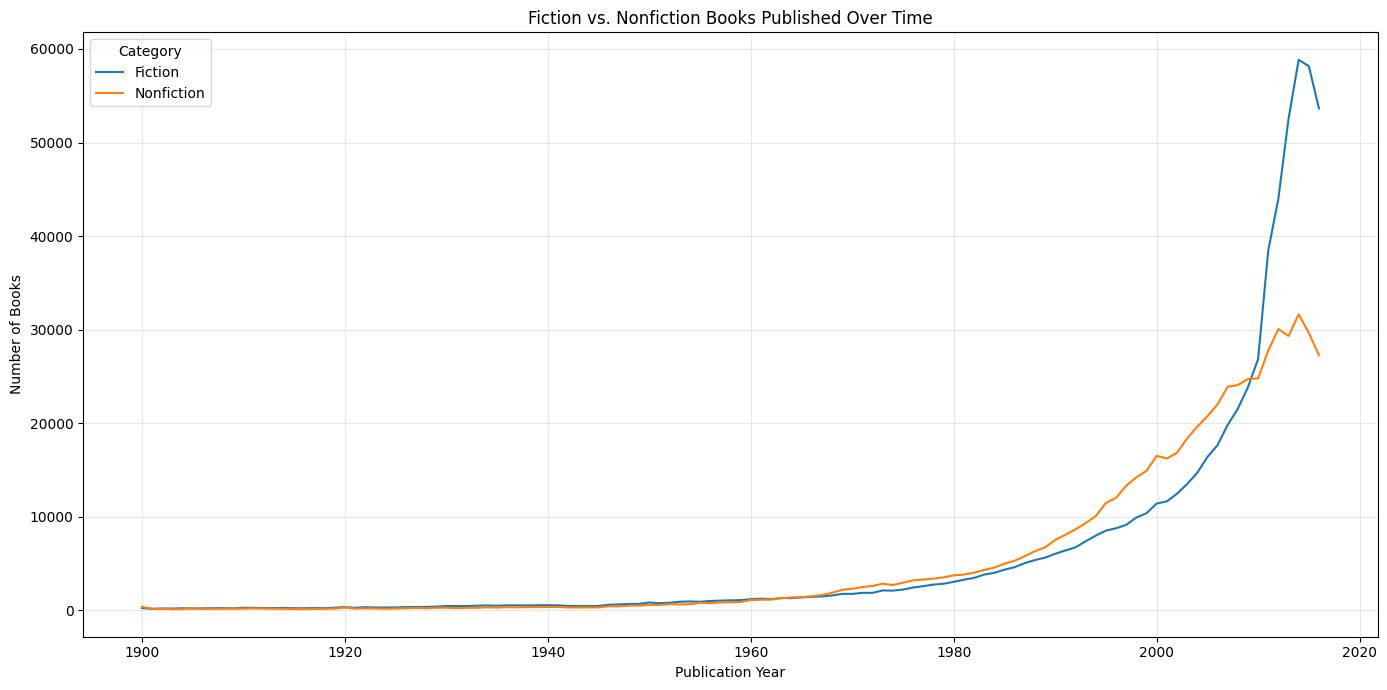

In [10]:
plt.figure(figsize=(14, 7))

for category in ["Fiction", "Nonfiction"]:
    subset = fiction_counts[
        fiction_counts["category"] == category
    ]

    plt.plot(
        subset["pub_year"],
        subset["book_count"],
        label=category
    )

plt.title("Fiction vs. Nonfiction Books Published Over Time")
plt.xlabel("Publication Year")
plt.ylabel("Number of Books")
plt.legend(title="Category")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Retrieve Specific Genre Trends

A SQL query retrieves each book's genre, publication year, and book ID to examine how individual genres change over time.

The query joins the `book_genres`, `genres`, and `books` tables through their primary and foreign key relationships.

The analysis is limited to books published between 1900 and 2016. The `audiobook` category is excluded because it represents a format rather than a literary genre.

This dataset will be used to identify which specific genres contribute most to the broader Fiction and Nonfiction trends observed in the first visualization.

In [18]:
genre_trends = pd.read_sql_query(
    """
    SELECT
        bg.genre_id,
        g.genre_name,
        b.pub_year,
        b.book_id
    FROM book_genres bg
    JOIN genres g
        ON bg.genre_id = g.genre_id
    JOIN books b
        ON bg.book_id = b.book_id
    WHERE b.pub_year BETWEEN 1900 AND 2016
      AND LOWER(g.genre_name) != 'audiobook'
    """,
    conn
)

## 12. Divide Publication Years into Two Time Periods

To make it easier to compare changes in genre representation across different eras, publication years are divided into two periods:

- **1900–1979**
- **1980–2016**

The `pd.cut()` function assigns each book to the appropriate time period based on its publication year.

These periods will be used to compare how the representation of individual genres changed between the earlier and later portions of the dataset.

In [19]:
genre_trends["period"] = pd.cut(
    genre_trends["pub_year"],
    bins=[1899, 1979, 2016],
    labels=["1900–1979", "1980–2016"]
)

## 13. Count Books by Genre and Time Period

The data is grouped by time period and genre to determine how many unique books are associated with each genre during each period.

The `nunique()` function is used on `book_id` so that each book is counted only once per genre and time period, even if it appears in multiple source datasets.

The resulting dataset provides the counts needed to compare the representation of individual genres between 1900–1979 and 1980–2016.

In [20]:
genre_period_counts = (
    genre_trends
    .groupby(["period", "genre_name"], observed=True)["book_id"]
    .nunique()
    .reset_index(name="book_count")
)

## 14. Identify the Top 10 Genres

The total number of books represented by each genre is calculated across both time periods.

The 10 genres with the highest combined book counts are selected for the visualization. Focusing on the most represented genres keeps the chart readable while highlighting the categories that have the greatest influence on the overall genre trends.

In [21]:
top_genres = (
    genre_period_counts
    .groupby("genre_name")["book_count"]
    .sum()
    .nlargest(10)
    .index
)

In [22]:
chart_2_data = genre_period_counts[
    genre_period_counts["genre_name"].isin(top_genres)
].copy()

## 15. Prepare Data for the Genre Trend Visualization

The dataset is filtered to include only the 10 most represented genres identified in the previous step.

This smaller dataset will be used to create the second visualization, allowing the changes in the most prominent individual genres to be compared across the two publication periods.

In [23]:
genre_change = (
    chart_2_data
    .pivot(
        index="genre_name",
        columns="period",
        values="book_count"
    )
    .fillna(0)
)

genre_change["change"] = (
    genre_change["1980–2016"] -
    genre_change["1900–1979"]
)

genre_change = genre_change.sort_values(
    "change",
    ascending=False
)

display(genre_change)

period,1900–1979,1980–2016,change
genre_name,,,
romance,5159,193946,188787
fantasy,7212,136678,129466
history,26294,147120,120826
contemporary,979,93641,92662
childrens,13347,102654,89307
comics,4618,86938,82320
mystery,9569,80088,70519
young adult,4108,67262,63154
science fiction,8912,66110,57198


## 16. Visualize Changes in Genre Representation

A horizontal bar chart is used to show how the representation of the top 10 genres changed between the two publication periods.

The change is calculated as the difference in the number of books represented in **1980–2016** compared with **1900–1979**.

- **Positive values** indicate that a genre became more represented in the later period.
- **Negative values** indicate that a genre became less represented in the later period.
- The vertical reference line at zero provides a clear baseline for interpreting increases and decreases.

This visualization helps identify which specific genres are driving the broader changes observed in the Fiction and Nonfiction trends.

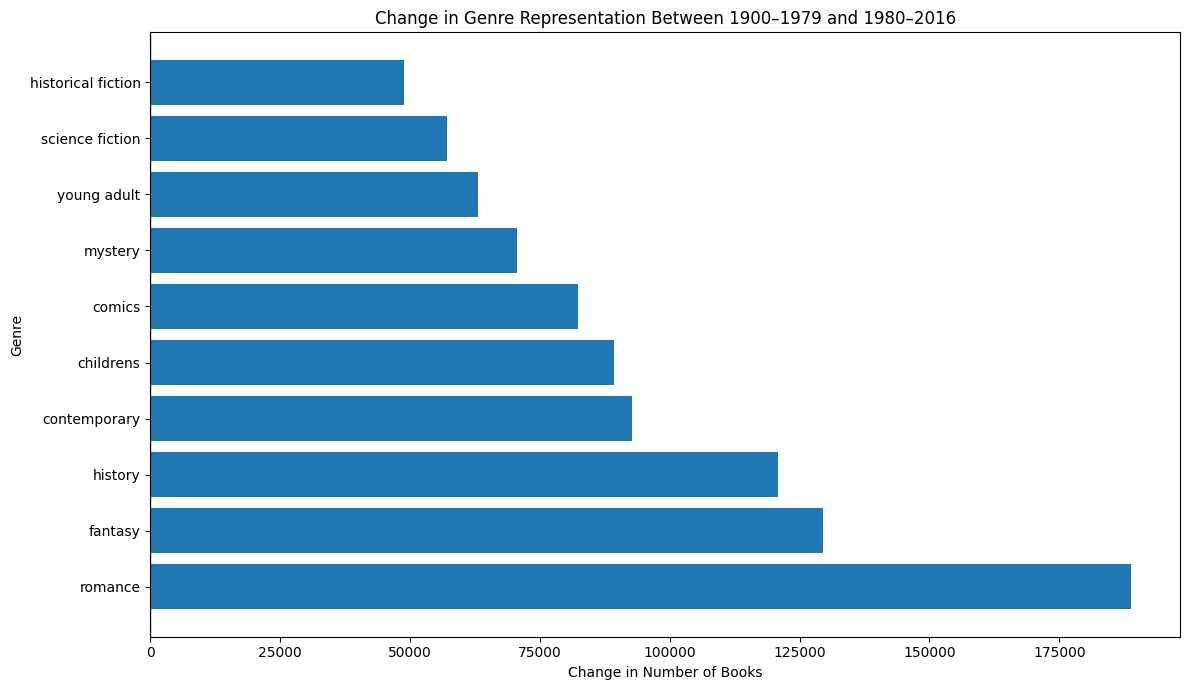

In [24]:
chart_2_plot = genre_change.reset_index()

plt.figure(figsize=(12, 7))

plt.barh(
    chart_2_plot["genre_name"],
    chart_2_plot["change"]
)

plt.axvline(0, linewidth=1)

plt.title(
    "Change in Genre Representation Between 1900–1979 and 1980–2016"
)

plt.xlabel("Change in Number of Books")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

## 17. Analyze Genre Representation and Reader Ratings

A SQL query is used to examine the relationship between genre representation and reader ratings.

For each genre, the query calculates:

- The number of unique books represented by the genre.
- The average Goodreads star rating.
- The total number of Goodreads ratings across those books.

Format-based and literary-form categories are excluded from this analysis, including `audiobook`, `ebooks`, `comics`, `picture books`, `short stories`, and `graphic novels`.

Only genres containing at least 100 unique books are included. This minimum sample size helps prevent genres with very few books from disproportionately influencing the comparison.

The resulting dataset is used to determine whether highly represented genres also tend to receive higher reader ratings.

In [32]:
genre_ratings = pd.read_sql_query(
    """
    SELECT
        g.genre_name,
        COUNT(DISTINCT b.book_id) AS book_count,
        ROUND(AVG(b.star_rating), 3) AS avg_rating,
        SUM(b.num_ratings) AS total_ratings
    FROM book_genres bg
    JOIN genres g
        ON bg.genre_id = g.genre_id
    JOIN books b
        ON bg.book_id = b.book_id
    WHERE b.pub_year BETWEEN 1900 AND 2016
      AND LOWER(g.genre_name) NOT IN (
          'audiobook',
          'ebooks',
          'comics',
          'picture books',
          'short stories',
          'graphic novels'
      )
      AND b.star_rating IS NOT NULL
    GROUP BY g.genre_id, g.genre_name
    HAVING COUNT(DISTINCT b.book_id) >= 100
    ORDER BY book_count DESC
    """,
    conn
)

display(genre_ratings.head(20))

,genre_name,book_count,avg_rating,total_ratings
0,romance,199105,3.828,579476065
1,history,173414,3.897,99069853
2,fantasy,143890,3.894,672257282
3,childrens,116001,3.902,231362034
4,contemporary,94620,3.809,425764038
5,mystery,89657,3.834,329198667
6,science fiction,75022,3.785,240443068
7,young adult,71370,3.859,536560514
8,historical fiction,68569,3.880,268633184
9,biography,66469,3.909,111243691


## 18. Visualize Genre Representation and Reader Ratings

A scatter plot is used to examine the relationship between the number of books represented by a genre and its average Goodreads rating.

Each point represents a genre:

- The **x-axis** shows the number of books represented by the genre on a logarithmic scale.
- The **y-axis** shows the genre's average Goodreads rating.
- The **size of each point** represents the total number of Goodreads ratings received by books in that genre.

The logarithmic x-axis makes it possible to compare genres with very different levels of representation.

This visualization explores whether more heavily represented genres tend to have different average reader ratings and provides additional context for understanding the popularity and reception of different genres.

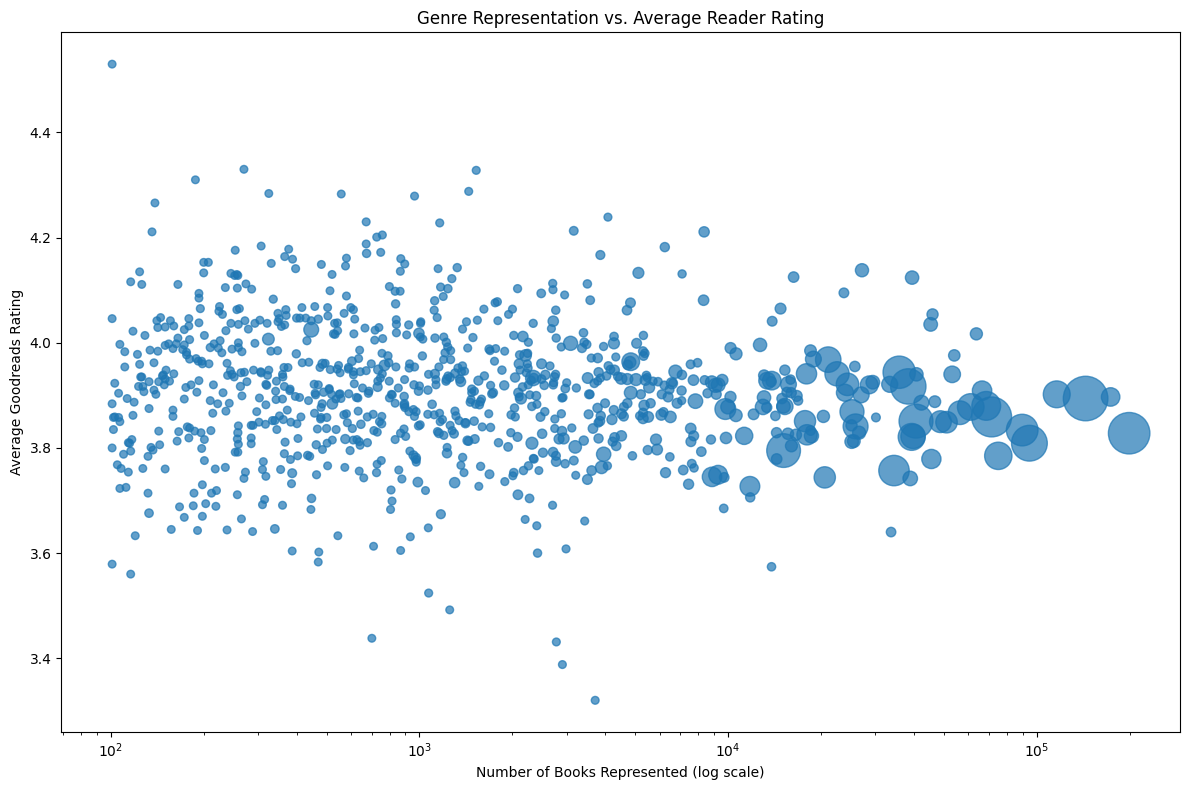

In [33]:
plt.figure(figsize=(12, 8))

plt.scatter(
    genre_ratings["book_count"],
    genre_ratings["avg_rating"],
    s=genre_ratings["total_ratings"] / genre_ratings["total_ratings"].max() * 1000 + 30,
    alpha=0.7
)

plt.xscale("log")

plt.title(
    "Genre Representation vs. Average Reader Rating"
)

plt.xlabel(
    "Number of Books Represented (log scale)"
)

plt.ylabel(
    "Average Goodreads Rating"
)

plt.tight_layout()
plt.show()

## 19. Highlight the Top 10 Most Represented Genres

To improve the readability of the genre comparison, the 10 most represented genres are identified and highlighted individually.

All remaining genres are grouped into an **"Other genres"** category and displayed with lower visual emphasis. The top 10 genres are plotted separately so they can be identified directly in the legend.

Point size continues to represent the total number of Goodreads ratings, while the logarithmic x-axis represents the number of books associated with each genre.

Additional spacing is added to the legend to make the genre labels easier to distinguish.

This refined visualization makes it easier to identify the most prominent genres while still showing the overall distribution of genre representation and average reader ratings.

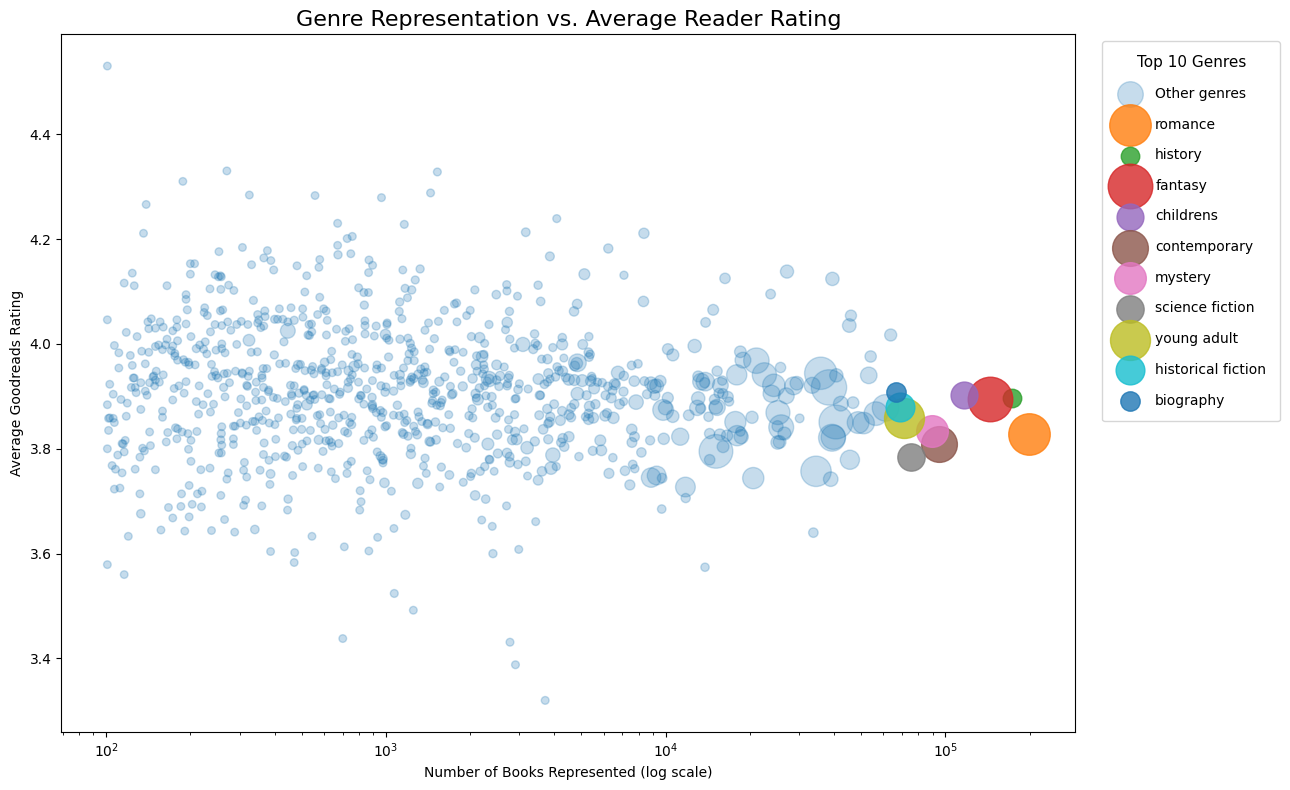

In [34]:
# Identify the 10 most represented genres
top_10_genres = (
    genre_ratings
    .nlargest(10, "book_count")
    ["genre_name"]
    .tolist()
)

# Create a category for the plot
genre_ratings["plot_group"] = genre_ratings["genre_name"].apply(
    lambda x: x if x in top_10_genres else "Other genres"
)

# Plot all other genres first
plt.figure(figsize=(13, 8))

other = genre_ratings[
    genre_ratings["plot_group"] == "Other genres"
]

plt.scatter(
    other["book_count"],
    other["avg_rating"],
    s=other["total_ratings"] / genre_ratings["total_ratings"].max() * 1000 + 30,
    alpha=0.25,
    label="Other genres"
)

# Plot each of the top 10 genres separately
for genre in top_10_genres:

    subset = genre_ratings[
        genre_ratings["genre_name"] == genre
    ]

    plt.scatter(
        subset["book_count"],
        subset["avg_rating"],
        s=subset["total_ratings"] / genre_ratings["total_ratings"].max() * 1000 + 30,
        alpha=0.8,
        label=genre
    )

plt.xscale("log")

plt.title(
    "Genre Representation vs. Average Reader Rating",
    fontsize=16
)

plt.xlabel(
    "Number of Books Represented (log scale)"
)

plt.ylabel(
    "Average Goodreads Rating"
)

plt.legend(
    title="Top 10 Genres",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    labelspacing=1.2,
    borderpad=1,
    title_fontsize=11
)

plt.tight_layout()
plt.show()